# Workshop 01
# Name : JISHA BOSSNE SJ
# Reg No : 212224230106

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Face')

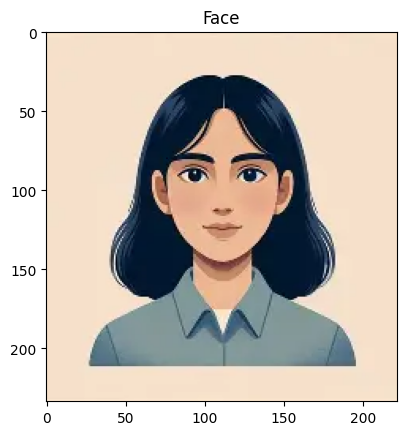

In [2]:
# Load the Face Image
faceImage = cv2.imread('photo.webp')
plt.imshow(faceImage[:,:,::-1]);plt.title("Face")


In [3]:
faceImage.shape

(234, 222, 3)

In [4]:
#resized_faceImage.shape
faceImage.shape

(234, 222, 3)

Text(0.5, 1.0, 'glassPNG')

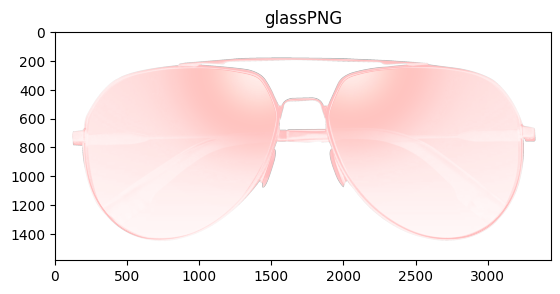

In [8]:
# Load the Sunglass image with Alpha channel
# (http://pluspng.com/sunglass-png-1104.html)
glassPNG = cv2.imread('Image-Source-PlusPNG.com.png',-1)
plt.imshow(glassPNG[:,:,::-1]);plt.title("glassPNG")

image Dimension =(50, 190, 4)


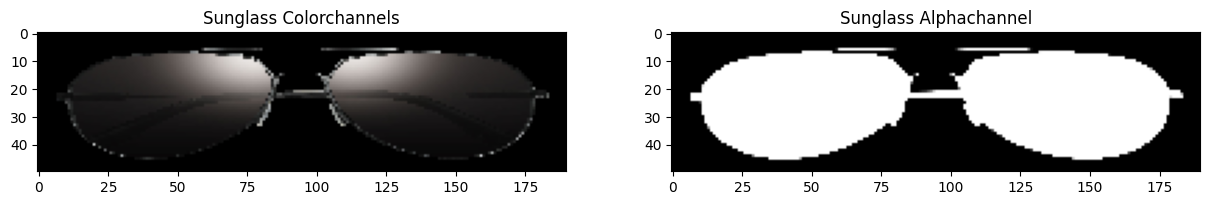

In [9]:
# Resize the image to fit over the eye region
glassPNG = cv2.resize(glassPNG,(190,50))
print("image Dimension ={}".format(glassPNG.shape))
# Separate the Color and alpha channels
glassBGR = glassPNG[:,:,0:3]
glassMask1 = glassPNG[:,:,3]
# Display the images for clarity
plt.figure(figsize=[15,15])
plt.subplot(121);plt.imshow(glassBGR[:,:,::-1]);plt.title('Sunglass Colorchannels');
plt.subplot(122);plt.imshow(glassMask1,cmap='gray');plt.title('Sunglass Alphachannel');


In [11]:
print(faceWithGlassesNaive.shape)

(234, 222, 3)


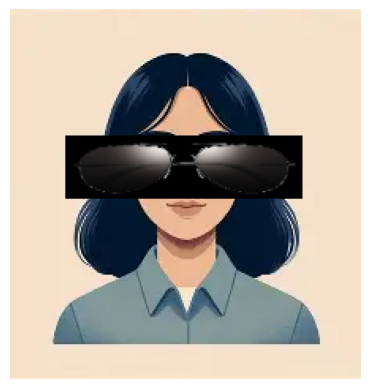

In [12]:
faceWithGlassesNaive = faceImage.copy()

glassBGR = cv2.resize(glassPNG[:, :, :3], (150, 40))

x, y = 35, 80

faceWithGlassesNaive[y:y+40, x:x+150] = glassBGR

plt.imshow(faceWithGlassesNaive[..., ::-1])
plt.axis("off")
plt.show()

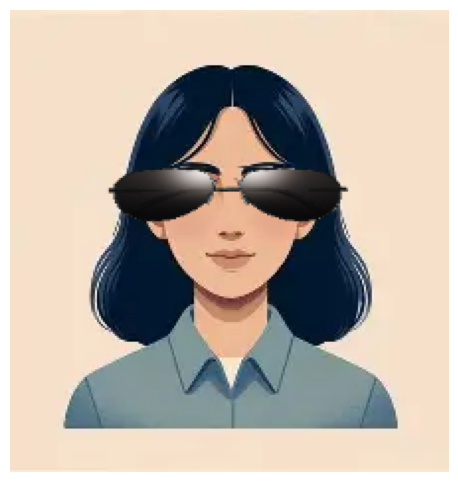

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

faceWithGlasses = faceImage.copy()

# Approximate eye region
x = 45
y = 75
w = 130
h = 35

# Resize glasses and mask
glassBGR = cv2.resize(glassPNG[:, :, :3], (w, h))

glassMask1 = cv2.resize(glassPNG[:, :, 3], (w, h))
glassMask = cv2.merge((glassMask1, glassMask1, glassMask1))
glassMask = glassMask.astype(np.float32) / 255.0

# Extract ROI
eyeROI = faceWithGlasses[y:y+h, x:x+w].astype(np.float32)

# Blend
maskedEye = eyeROI * (1 - glassMask)
maskedGlass = glassBGR.astype(np.float32) * glassMask

eyeRoiFinal = (maskedEye + maskedGlass).astype(np.uint8)

# Put back into image
faceWithGlasses[y:y+h, x:x+w] = eyeRoiFinal

# Display
plt.figure(figsize=(6,6))
plt.imshow(faceWithGlasses[:,:,::-1])
plt.axis("off")
plt.show()

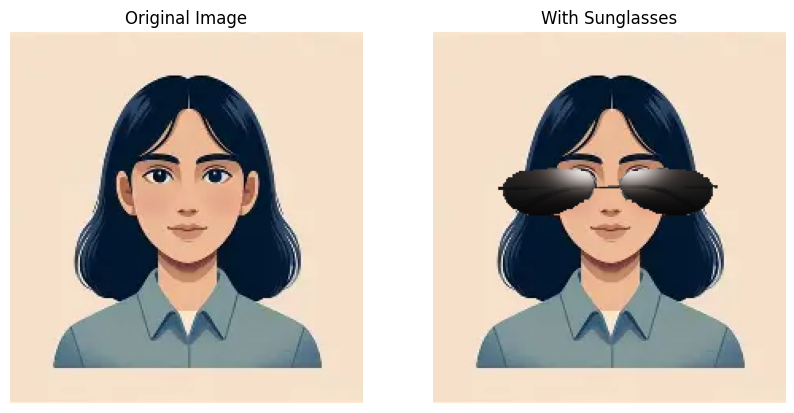

In [16]:
x = 35
y = 80

eyeROI = faceWithGlassesArithmetic[y:y+40, x:x+150]

maskedEye = cv2.multiply(eyeROI, (1 - glassMask))
maskedGlass = cv2.multiply(glassBGR, glassMask)

eyeRoiFinal = cv2.add(maskedEye, maskedGlass)

faceWithGlassesArithmetic[y:y+40, x:x+150] = eyeRoiFinal

plt.figure(figsize=[10,5])

plt.subplot(121)
plt.imshow(faceImage[:,:,::-1])
plt.title("Original Image")
plt.axis("off")

plt.subplot(122)
plt.imshow(faceWithGlassesArithmetic[:,:,::-1])
plt.title("With Sunglasses")
plt.axis("off")

plt.show()